# BioVision-Path
## Multi-Task Biomedical Image Analysis Dashboard

### OBJECTIVE
This notebook ties all three tasks—Classification, Segmentation, and Detection—into a single visual dashboard.
It automatically loads model checkpoints, allows selection of tasks, and generates overlays (Grad-CAM heatmaps, segmentation masks, bounding boxes).

### 1. Setup & Imports

In [1]:
# Environment Report & CUDA Detection
import sys
import torch
import torchvision
from src.reproducibility import print_environment_report, set_seed
from src.config import CONFIG

# Print report
env = print_environment_report()
set_seed(CONFIG["seed"])


                    ENVIRONMENT REPORT                    
Python Version    : 3.10.9
PyTorch Version   : 2.13.0+cpu
CUDA Available    : False
GPU Name          : None (CPU Fallback)
[Notice] CUDA is not available. System is running in CPU fallback mode.
         In GPU environments (like Colab GPU runtime), this will significantly slow training.
         Please check runtime settings if a GPU was expected.
[Reproducibility] Random seed set to: 42


### 2. Loading Checkpoints

In [2]:
# Check checkpoints availability
from src.models import get_resnet18_model, UNet, get_faster_rcnn_mobilenet_v3
from src.data import get_pathmnist_metadata
import os

meta = get_pathmnist_metadata()

# 1. Classification
cls_model = get_resnet18_model(num_classes=meta["n_classes"], pretrained=False).to(CONFIG["device"])
c_path = "checkpoints/resnet18_classification.pth"
if os.path.exists(c_path):
    cls_model.load_state_dict(torch.load(c_path, map_location=CONFIG["device"]))
    print("Classification checkpoint loaded.")
    
# 2. Segmentation
seg_model = UNet().to(CONFIG["device"])
s_path = "checkpoints/unet_segmentation.pth"
if os.path.exists(s_path):
    seg_model.load_state_dict(torch.load(s_path, map_location=CONFIG["device"]))
    print("Segmentation checkpoint loaded.")
    
# 3. Detection
det_model = get_faster_rcnn_mobilenet_v3(num_classes=4, pretrained=False).to(CONFIG["device"])
d_path = "checkpoints/faster_rcnn_detection.pth"
if os.path.exists(d_path):
    det_model.load_state_dict(torch.load(d_path, map_location=CONFIG["device"]))
    print("Detection checkpoint loaded.")


Classification checkpoint loaded.
Segmentation checkpoint loaded.


Detection checkpoint loaded.


### 3. Matplotlib Fallback Demo interface

=== Classification and Interpretability Demo ===


[Data] DEMO MODE: Subsetting datasets. Train: 20, Val: 10, Test: 10


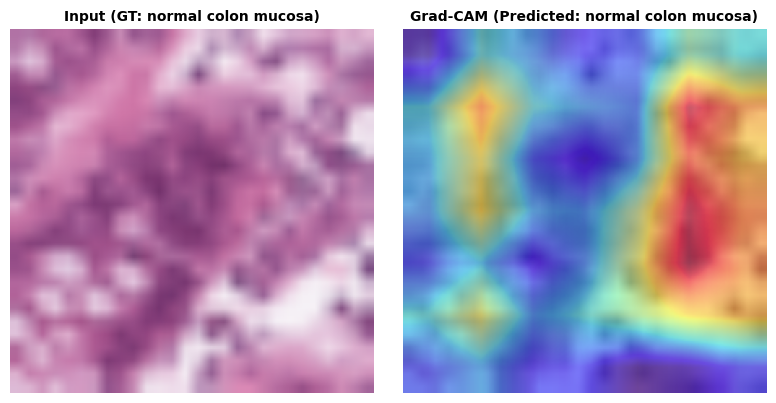


=== U-Net Segmentation Demo ===
[Dataset] Found 50 image-mask pairs in TNBC dataset.
[Dataset] Found 50 image-mask pairs in TNBC dataset.
[Dataset] DEMO MODE: Subsetting TNBC dataset. Train: 8, Val: 2, Test: 2


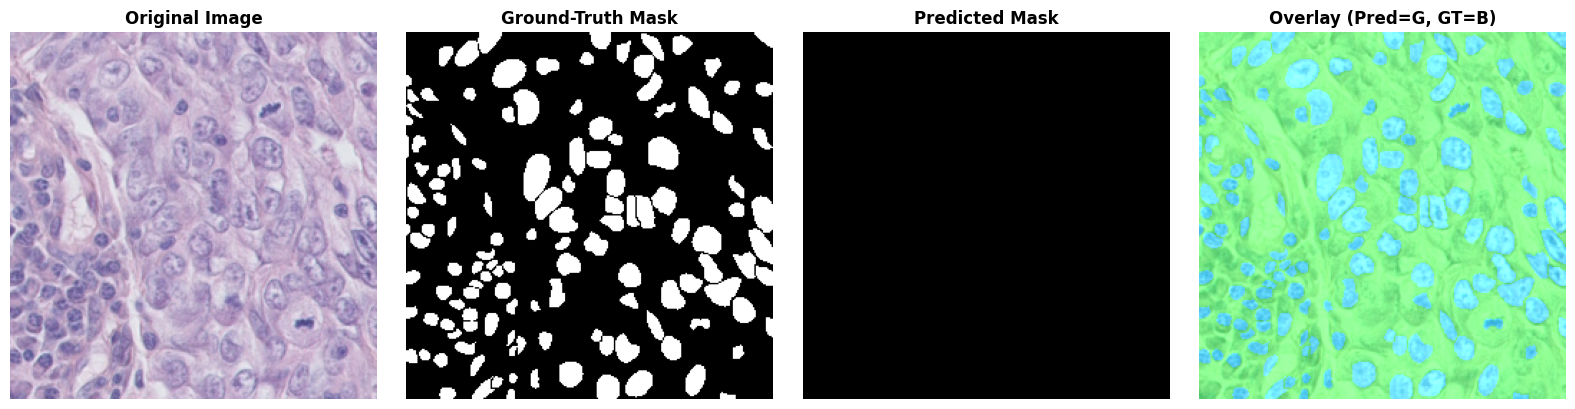


=== Object Detection Demo ===
[Dataset] DEMO MODE: Subsetting BCCD dataset. Train: 20, Val: 5


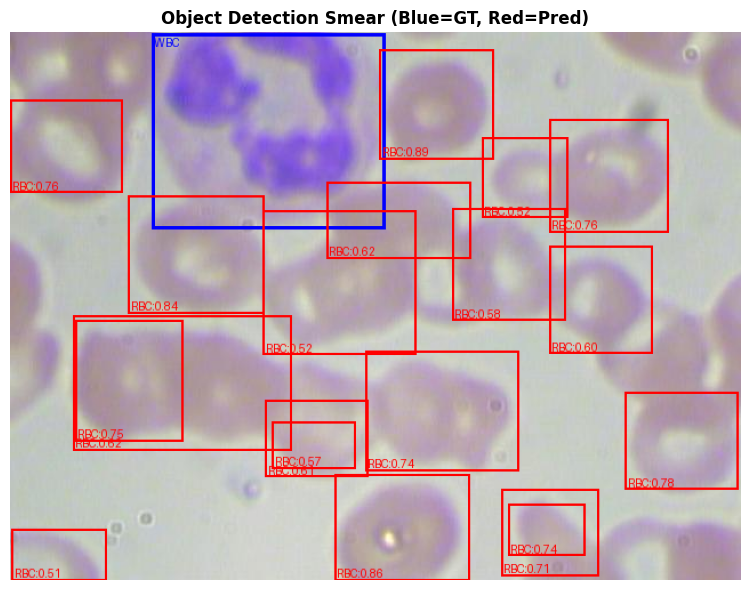

In [3]:
# Visual dashboard demonstrating results
import matplotlib.pyplot as plt
from src.segmentation import get_tnbc_dataloaders
from src.detection import get_bccd_dataloaders
from src.data import get_pathmnist_dataloaders
from src.preprocessing import get_classification_transforms
from src.visualization import plot_segmentation_predictions, plot_detection_predictions
from src.explainability import GradCAM, overlay_gradcam_on_image

# 1. Classification & Grad-CAM Demo
print("=== Classification and Interpretability Demo ===")
train_trans, val_trans = get_classification_transforms(224)
_, _, cls_test = get_pathmnist_dataloaders(16, 224, train_trans, val_trans, val_trans, demo_mode=True, subset_size=20)
cls_imgs, cls_lbls = next(iter(cls_test))

# Compute Grad-CAM
gradcam = GradCAM(cls_model, cls_model.layer4)
img_tensor = cls_imgs[0:1].to(CONFIG["device"])
heatmap, pred_c = gradcam.generate_heatmap(img_tensor)
gradcam.close()

# Plot
from src.visualization import denormalize_image
original_np = denormalize_image(cls_imgs[0], mean=[0.707, 0.522, 0.672], std=[0.166, 0.186, 0.158])
blended, _ = overlay_gradcam_on_image(original_np, heatmap, alpha=0.5)

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(original_np)
axes[0].set_title(f"Input (GT: {meta['classes'][str(cls_lbls[0].item())]})", fontsize=10, fontweight="bold")
axes[0].axis("off")
axes[1].imshow(blended)
axes[1].set_title(f"Grad-CAM (Predicted: {meta['classes'][str(pred_c)]})", fontsize=10, fontweight="bold")
axes[1].axis("off")
plt.tight_layout()
plt.show()

# 2. Segmentation U-Net Demo
print("\n=== U-Net Segmentation Demo ===")
_, _, seg_test = get_tnbc_dataloaders(CONFIG["data_dir"]+"/TNBC_NucleiSegmentation", 4, 256, demo_mode=True)
seg_imgs, seg_masks = next(iter(seg_test))
seg_model.eval()
with torch.no_grad():
    seg_preds = torch.sigmoid(seg_model(seg_imgs.to(CONFIG["device"])))
    seg_preds_m = (seg_preds > 0.5).float()
plot_segmentation_predictions(seg_imgs[0], seg_masks[0], seg_preds_m[0])

# 3. Detection Demo
print("\n=== Object Detection Demo ===")
_, det_test = get_bccd_dataloaders(CONFIG["data_dir"]+"/BCCD", 2, (480, 640), demo_mode=True)
det_imgs, det_targets = next(iter(det_test))
det_model.eval()
with torch.no_grad():
    det_preds = det_model([img.to(CONFIG["device"]) for img in det_imgs])
plot_detection_predictions(det_imgs[0], det_targets[0], det_preds[0], class_names=CONFIG["detection"]["classes"])


### 4. Interactive Gradio Interface (Optional)
Gradio allows creating a web interface inside Google Colab. The code block below checks if gradio is imported and boots up the multi-task dashboard.

In [4]:
# Gradio app launch
try:
    import gradio as gr
    print("Gradio is available. We can run the web dashboard.")
except ImportError:
    print("Gradio is not available. Please run: pip install gradio to use the interactive dashboard.")


Gradio is available. We can run the web dashboard.
